In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import numpy as np


# set random seed
np.random.seed(42)

from LISA_utils import PowerSpectralDensity, FFT, freq_PSD, inner_prod, waveform

np.random.seed(1234)

def waveform(params):
    """
    This is a function. It takes in a value of the amplitude $a$, frequency $f$ and frequency derivative $\dot{f}
    and a time vector $t$ and spits out whatever is in the return function. Modify amplitude to improve SNR. 
    Modify frequency range to also affect SNR but also to see if frequencies of the signal are important 
    for the windowing method. We aim to estimate the parameters $a$, $f$ and $\dot{f}$.
    """
    a = params[0]
    f = params[1]
    fdot = params[2]

    return (a *(np.sin((2*np.pi)*(f*t + 0.5*fdot * t**2))))

def modify_PSD(freq_bin, scale = 1):
    PSD = PowerSpectralDensity(freq_bin)
    PSD_modified = scale * PSD
    return PSD_modified

def deriv_waveform(params,phi):
    """
    This is a function. It takes in a value of the amplitude $a$, frequency $f$ and frequency derivative $\dot{f}
    and a time vector $t$ and spits out whatever is in the return function. Modify amplitude to improve SNR. 
    Modify frequency range to also affect SNR but also to see if frequencies of the signal are important 
    for the windowing method. We aim to estimate the parameters $a$, $f$ and $\dot{f}$.
    """
    a = params[0]
    f = params[1]
    fdot = params[2]

    return (a *(np.sin((2*np.pi)*(f*t + 0.5*fdot * t**2) + phi) ))

def Gaussian(values,mean,std):
    return np.exp(-(values - mean)**2 / (2*std**2))



def llike(params, data_f, variance_noise_f):
    """
    Computes log likelihood 
    Assumption: Known PSD otherwise need additional term
    Inputs:
    data in frequency domain 
    Proposed signal in frequency domain
    Variance of noise
    """

    signal_prop_t = waveform(params)
    signal_prop_f = FFT(signal_prop_t)

    inn_prod = sum((abs(data_f - signal_prop_f)**2) / variance_noise_f)

    return(-0.5 * inn_prod)

# Set true parameters

a_true = 1e-21
f_true = 1e-3
fdot_true = 1e-8  

true_params = [a_true,f_true,fdot_true]
N_params = len(true_params)



In [3]:
tmax =  120*60*60                 # Final time
fs = 2*f_true                     # Sampling rate
delta_t = np.floor(0.01/fs)       # Sampling interval

t = np.arange(0,tmax,delta_t)     # Form time vector from t0 = 0 to t_{n-1} = tmax. Length N [include zero]

N_t = int(2**(np.ceil(np.log2(len(t)))))   # Round length of time series to a power of two. 
                                           # Length of time series

h_true_t = waveform(true_params)

h_true_f = FFT(h_true_t)         # Compute true signal in
                                                            # frequency domain. Real signal so only considering
                                                            # positive frequencies here.

freq,PSD = freq_PSD(t,delta_t)  # Extract frequency bins and PSD.

SNR2 = inner_prod(h_true_f,h_true_f,PSD,delta_t,N_t)    # Compute optimal matched filtering SNR
print("SNR of source",np.sqrt(SNR2))

# Compute FM

exact_deriv_a = (a_true)** -1  * deriv_waveform(true_params, 0)
deriv_a_fft = FFT(exact_deriv_a)

exact_deriv_f = (2*np.pi*t) * deriv_waveform(true_params, np.pi/2)
deriv_f_fft = FFT(exact_deriv_f)

exact_deriv_fdot = (0.5) * (2*np.pi * t**2) * deriv_waveform(true_params, np.pi/2)
deriv_fdot_fft = FFT(exact_deriv_fdot)

deriv_vec = [deriv_a_fft, deriv_f_fft, deriv_fdot_fft]
Fisher_Matrix = np.eye(N_params)
for i in range(N_params):
    for j in range(N_params):
        Fisher_Matrix[i,j] = inner_prod(deriv_vec[i],deriv_vec[j],PSD,delta_t,N_t)

Cov_Matrix = np.linalg.inv(Fisher_Matrix)

precision = np.sqrt(np.diag(Cov_Matrix))




SNR of source 37.62621970275949


In [128]:

# Now compute Cutler valisneri biases due to noise 

variance_noise_f = N_t * PSD / (4 * delta_t)            # Calculate variance of noise, real and imaginary.
N_f = len(variance_noise_f)                             # Length of signal in frequency domain

noise_bias_f_list = []
from tqdm import tqdm as tqdm
for j in tqdm(range(0,15000)):
    noise_f_seed = np.random.normal(0,np.sqrt(variance_noise_f),N_f) + 1j*np.random.normal(0,np.sqrt(variance_noise_f),N_f)

    b_vec = [inner_prod(noise_f_seed,deriv_vec[i],PSD,delta_t,N_t) for i in range(N_params)]
    noise_bias_f = true_params + Cov_Matrix @ b_vec

    noise_bias_f_list.append(noise_bias_f)



100%|██████████| 15000/15000 [02:24<00:00, 103.80it/s]


[]

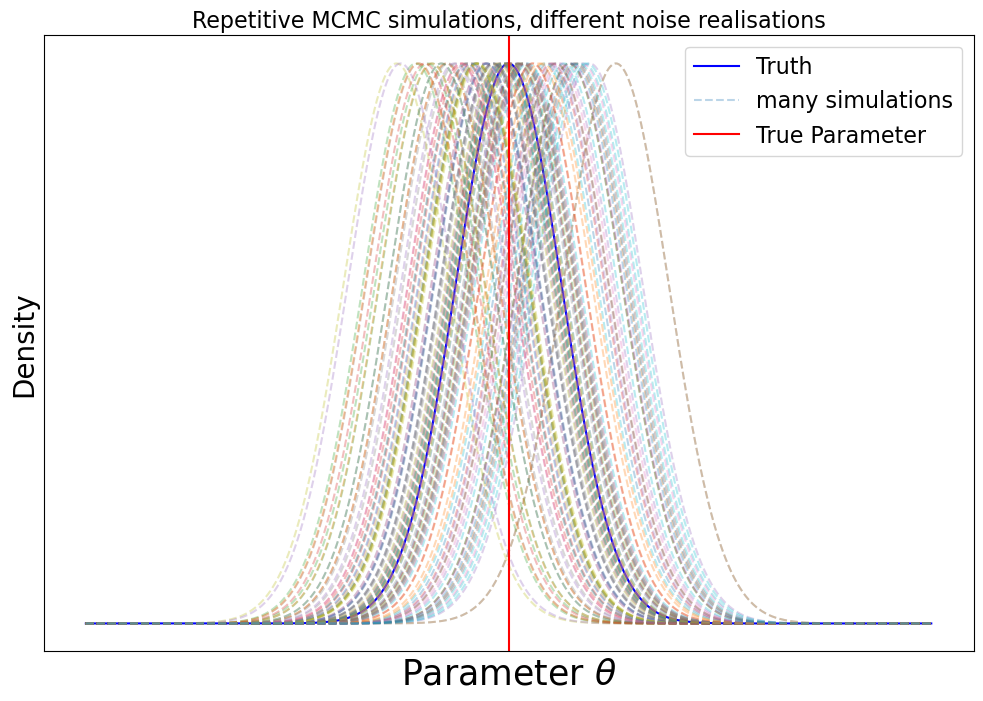

In [129]:
save_direc = '/Users/ollie.burke/Documents/Work/Code/Tutorials/Fisher_Matrix/plots/bias_plots'
# ----------- Take a random selection of points with FM uncertainty ------------

# Create smooth gaussian distribution for parameter 0
# Deal with multiple noise biases 
x_range = np.linspace(true_params[0] - 8*np.sqrt(Cov_Matrix[0,0]), 
                      true_params[0] + 8*np.sqrt(Cov_Matrix[0,0]), 1000)

mean_vals = np.array(noise_bias_f_list)[:,0]
uncertainty_param_0 = precision[0]

list_y_gaussian = [Gaussian(x_range, mean_vals[j], np.sqrt(Cov_Matrix[0,0])) for j in range(len(mean_vals))]

param_0_values = [noise_bias_f_list[j][0] for j in range(len(noise_bias_f_list))]
true_gaussian = Gaussian(x_range, true_params[0], np.sqrt(Cov_Matrix[0,0]))

# ============ Plot
fig,ax = plt.subplots(1,1, figsize = (12,8))
ax.plot(x_range, true_gaussian, label = 'Truth', alpha = 1, c = 'blue', linestyle = '-')
step = 5

first_plot = 1
# final_plot = 100
# for i in range(0,first_plot,step):
ax.plot(x_range, list_y_gaussian[30],  label = 'many simulations', alpha = 0.3, linestyle = '--')
# ax.set_yticks([])

second_plot = 2
third_plot = 3
fourth_plot = 4
final_plot = 100
for i in range(0,final_plot):
    ax.plot(x_range, list_y_gaussian[i],  alpha = 0.3, linestyle = '--')
    ax.set_yticks([])

ax.axvline(x = true_params[0], c = 'red', label = 'True Parameter')
ax.legend(fontsize = 16)
ax.set_ylabel("Density", fontsize = 20)
ax.set_xlabel(r"Parameter $\theta$", fontsize = 25)
ax.set_title('Repetitive MCMC simulations, different noise realisations', fontsize = 16)
ax.set_xticks([])
# plt.savefig(save_direc + "/many_simulations.pdf", bbox_inches = "tight")


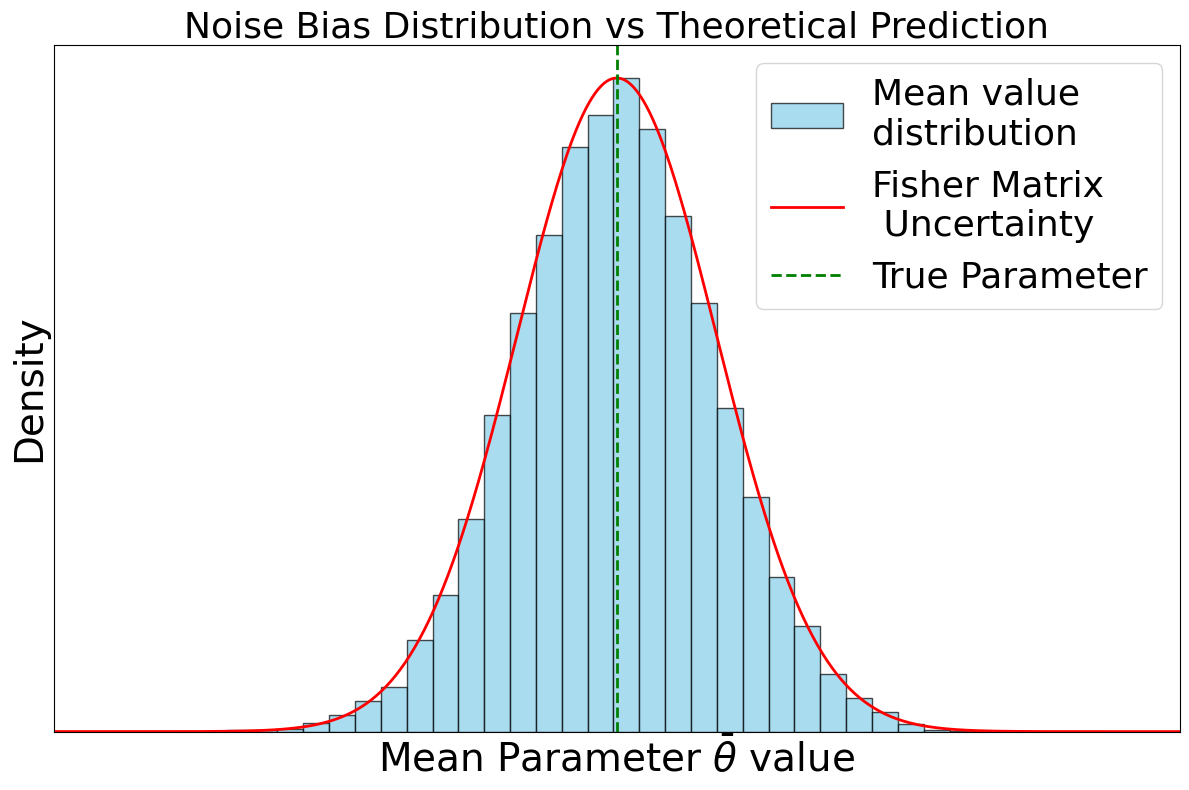

In [130]:
# Extract parameter 0 values from noise bias list
fig,ax = plt.subplots(1,1, figsize = (12,8))

hist_counts, _, _ = ax.hist(param_0_values, bins=30, alpha=0.7, density=False, 
                            label='Mean value \ndistribution', color='skyblue', edgecolor='black')
max_bin_height = np.max(hist_counts)

# Now compute average bias
#
true_gaussian = max_bin_height * Gaussian(x_range, true_params[0], np.sqrt(Cov_Matrix[0,0]))
ax.plot(x_range, true_gaussian, label='Fisher Matrix\n Uncertainty', 
    color='red', linewidth=2)

# Add vertical line for true parameter value
ax.axvline(true_params[0], color='green', linestyle='--', 
       linewidth=2, label='True Parameter')

# Formatting
ax.set_xlabel(r'Mean Parameter $\bar{\theta}$ value', fontsize = 28)
#a].set_ylabel('Density')
ax.set_yticks([])
ax.tick_params(size = 16)
ax.set_title('Noise Bias Distribution vs Theoretical Prediction', fontsize = 26)
# 1].tick_params(fontsize = 16)
ax.legend(fontsize = 26)
ax.grid(True, alpha=0.3)

ax.set_xlim([0.85*1e-21, 1.15*1e-21])
ax.set_ylabel(r'Density', fontsize = 28)
ax.set_xticks([])

plt.tight_layout()
# plt.savefig(save_direc + "/averaged_simulations_correct_noise.pdf", bbox_inches = "tight")
plt.show()

[]

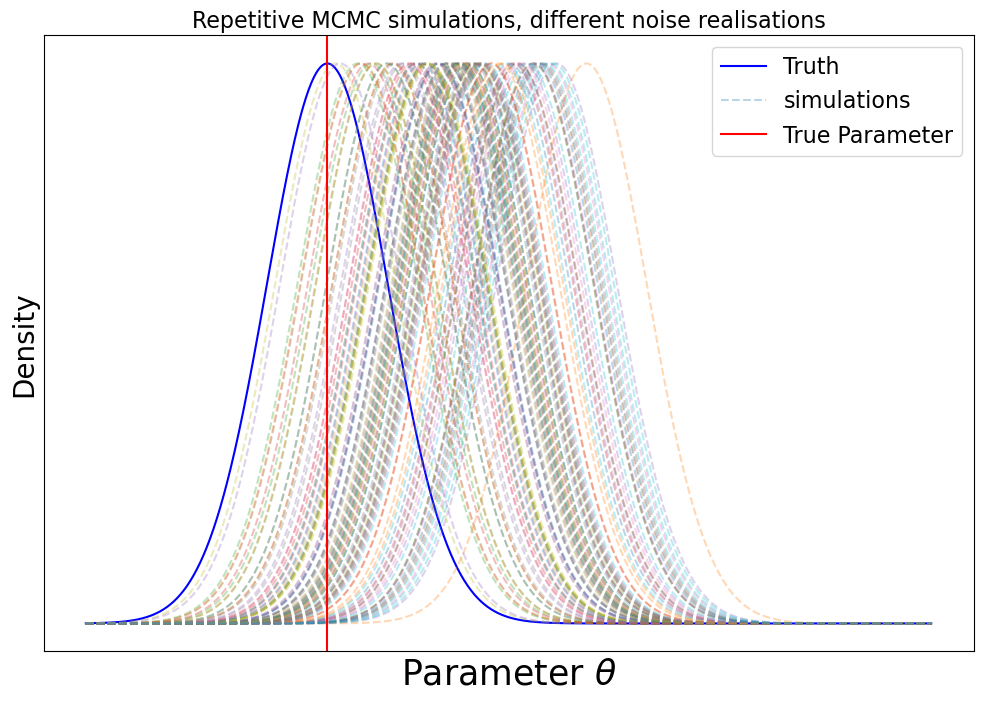

In [131]:
save_direc = '/Users/ollie.burke/Documents/Work/Code/Tutorials/Fisher_Matrix/plots/bias_plots'
# ----------- Take a random selection of points with FM uncertainty ------------

# Create smooth gaussian distribution for parameter 0
# Deal with multiple noise biases 
x_range = np.linspace(true_params[0] - 4*np.sqrt(Cov_Matrix[0,0]), 
                      true_params[0] + 10*np.sqrt(Cov_Matrix[0,0]), 1000)

shift = 0.6e-22
mean_vals_shift = 0.6e-22 + np.array(noise_bias_f_list)[:,0]
uncertainty_param_0 = precision[0]

list_y_gaussian = [Gaussian(x_range, mean_vals_shift[j], np.sqrt(Cov_Matrix[0,0])) for j in range(len(mean_vals))]

param_0_values = [noise_bias_f_list[j][0] for j in range(len(noise_bias_f_list))]
true_gaussian = Gaussian(x_range, true_params[0], np.sqrt(Cov_Matrix[0,0]))

# ============ Plot
fig,ax = plt.subplots(1,1, figsize = (12,8))
ax.plot(x_range, true_gaussian, label = 'Truth', alpha = 1, c = 'blue', linestyle = '-')
step = 5

first_plot = 1
# final_plot = 100
# for i in range(0,first_plot,step):
ax.plot(x_range, list_y_gaussian[29],  label = 'simulations', alpha = 0.3, linestyle = '--')
# ax.set_yticks([])

second_plot = 2
third_plot = 3
fourth_plot = 4
final_plot = 100
for i in range(0,final_plot):

    ax.plot(x_range, list_y_gaussian[i],  alpha = 0.3, linestyle = '--')
    ax.set_yticks([])

ax.axvline(x = true_params[0], c = 'red', label = 'True Parameter')
ax.legend(fontsize = 16)
ax.set_ylabel("Density", fontsize = 20)
ax.set_xlabel(r"Parameter $\theta$", fontsize = 25)
ax.set_title('Repetitive MCMC simulations, different noise realisations', fontsize = 16)
ax.set_xticks([])
ax.set_yticks([])
# plt.savefig(save_direc + "/many_simulations_ystematics.pdf", bbox_inches = "tight")


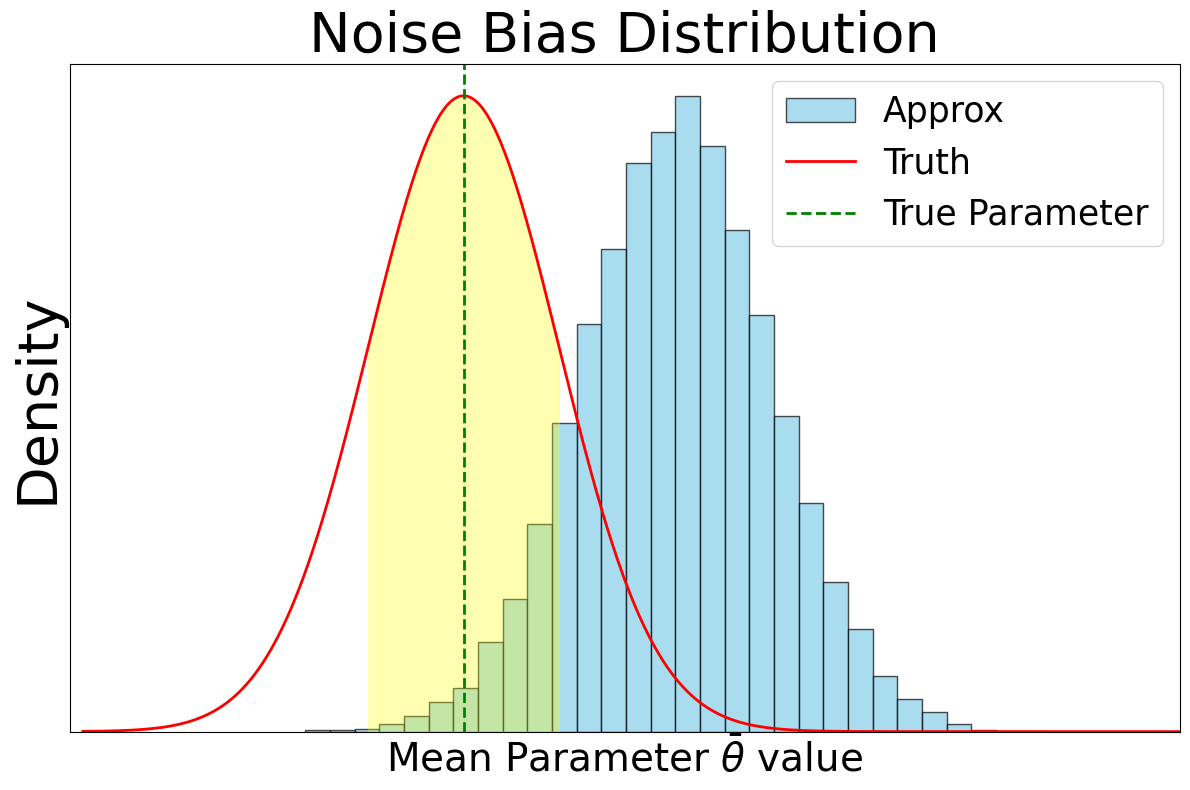

In [133]:
# Extract parameter 0 values from noise bias list
fig,ax = plt.subplots(1,1, figsize = (12,8))

shift = 0.6e-22
param_0_values_shift = [shift + noise_bias_f_list[j][0] for j in range(len(noise_bias_f_list))]
hist_counts, _, _ = ax.hist(param_0_values_shift, bins=30, alpha=0.7, density=False, 
                            label='Approx', color='skyblue', edgecolor='black')
max_bin_height = np.max(hist_counts)

# Now compute average bias
#
true_gaussian = max_bin_height * Gaussian(x_range, true_params[0], np.sqrt(Cov_Matrix[0,0]))
ax.plot(x_range, true_gaussian, label='Truth', 
    color='red', linewidth=2)

# Add vertical line for true parameter value
ax.axvline(true_params[0], color='green', linestyle='--', 
       linewidth=2, label='True Parameter')

# Formatting
ax.set_xlabel(r'Mean Parameter $\bar{\theta}$ value', fontsize = 28)
#a].set_ylabel('Density')
ax.set_yticks([])
ax.tick_params(size = 16)
ax.set_ylabel(r'Density', fontsize = 40)
ax.set_title('Noise Bias Distribution', fontsize = 40)
# 1].tick_params(fontsize = 16)
ax.set_xlim([0.89*1e-21,1.20*1e-21])
ax.legend(fontsize = 25)
ax.grid(True, alpha=0.3)
px = np.linspace(true_params[0] - np.sqrt(Cov_Matrix[0,0]), true_params[0] + np.sqrt(Cov_Matrix[0,0]), 1000)
ax.fill_between(px,max_bin_height*np.exp(-0.5 * (px - true_params[0])**2 / Cov_Matrix[0,0]),color='yellow', alpha = 0.3)
ax.set_xticks([])
plt.savefig(save_direc + "/averaged_simulations_systematics.pdf", bbox_inches = "tight")
plt.tight_layout()

# Try to muck up the stimation of the noise

In [149]:
PSD_true = PSD
scale = 0.1
PSD_overestimate =  scale * PSD_true

Fisher_Matrix_scaled = np.eye(N_params)
for i in range(N_params):
    for j in range(N_params):
        Fisher_Matrix_scaled[i,j] = inner_prod(deriv_vec[i],deriv_vec[j],PSD_overestimate,delta_t,N_t)

# Now compute Cutler valisneri biases due to noise 

Cov_Matrix_scaled = np.linalg.inv(Fisher_Matrix_scaled)
variance_noise_f_true = N_t * PSD_true / (4 * delta_t)            # Calculate variance of noise, real and imaginary.
N_f = len(variance_noise_f)                             # Length of signal in frequency domain

noise_bias_f_scaled_list = []
from tqdm import tqdm as tqdm
for j in tqdm(range(0,1000)):
    noise_f_seed_true = np.random.normal(0,np.sqrt(variance_noise_f_true),N_f) + 1j*np.random.normal(0,np.sqrt(variance_noise_f_true),N_f)

    b_vec_true = [inner_prod(noise_f_seed_true,deriv_vec[i],PSD_overestimate,delta_t,N_t) for i in range(N_params)]
    noise_bias_f_scaled = true_params + Cov_Matrix_scaled @ b_vec_true

    noise_bias_f_scaled_list.append(noise_bias_f_scaled)

100%|██████████| 1000/1000 [00:09<00:00, 104.32it/s]


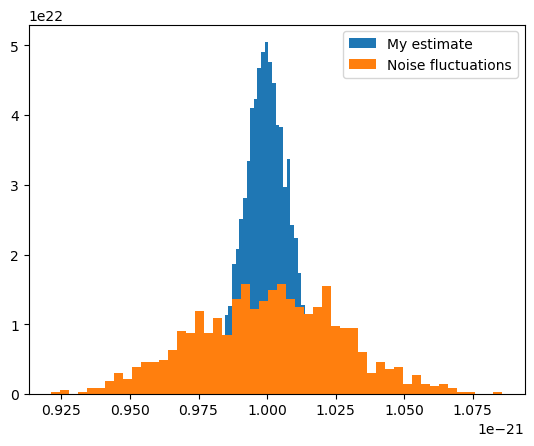

In [150]:
check = np.random.normal(1e-21, np.sqrt(Cov_Matrix_scaled[0,0]), 5000)

plt.hist(check, bins = 50, density = True, label = 'My estimate')
plt.hist(np.array(noise_bias_f_scaled_list)[:,0], bins = 50, density = True, label = 'Noise fluctuations')
plt.legend()